Iteration    0 | Cost: 2314304.6280
Iteration  100 | Cost: 1225458.3974
Iteration  200 | Cost: 736992.5133
Iteration  300 | Cost: 517862.4715
Iteration  400 | Cost: 419558.8300
Iteration  500 | Cost: 375458.9618
Iteration  600 | Cost: 355675.3776
Iteration  700 | Cost: 346800.2898
Iteration  800 | Cost: 342818.8482
Iteration  900 | Cost: 341032.7389


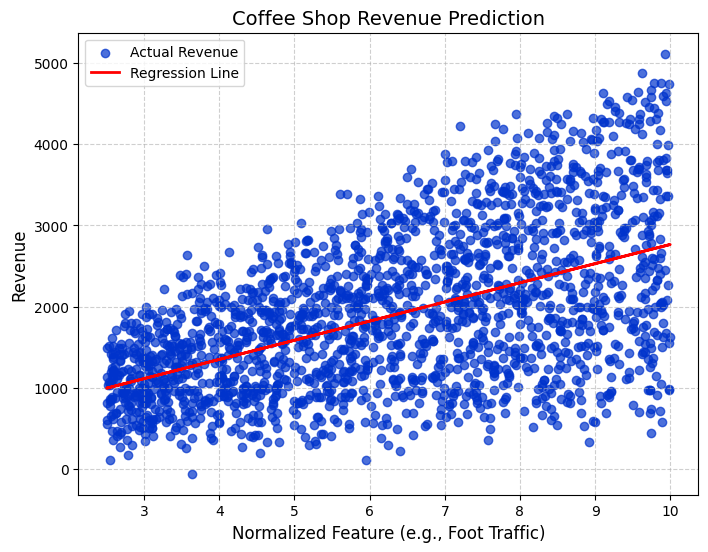

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class SimpleLinearRegression:
    def __init__(self, learning_rate=0.004, iterations=1000):
        """Initialize the model with hyperparameters."""
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def predict(self, X):
        """Calculate the hypothesis (y = wx + b)."""
        return np.dot(X, self.weights) + self.bias

    def fit(self, X, y):
        """Train the model using Gradient Descent."""
        n_samples, n_features = X.shape
        
        # Initialize parameters
        self.weights = np.random.normal(loc=0.0, scale=0.01, size=(n_features, 1))
        self.bias = np.zeros((1, 1))

        for i in range(self.iterations):
            y_predicted = self.predict(X)

            # Calculate gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Calculate and store the cost (Mean Squared Error)
            cost = (1 / (2 * n_samples)) * np.sum((y_predicted - y) ** 2)
            self.cost_history.append(cost)

            if i % 100 == 0:
                print(f"Iteration {i:4d} | Cost: {cost:.4f}")

def main():
    # 1. Load the Data
    df = pd.read_csv('coffee_shop_revenue.csv')
    
    # Extract features (X) and target (y)
    X = df.iloc[:, 1].to_numpy().reshape(-1, 1)  # 2nd column
    y = df.iloc[:, -1].to_numpy().reshape(-1, 1) # Last column

    # 2. Normalize the Feature (Z-score normalization)
    X_norm = (X - np.mean(X)) / np.std(X)

    # 3. Initialize and Train the Model
    model = SimpleLinearRegression(learning_rate=0.004, iterations=1000)
    model.fit(X_norm, y)

    # 4. Make Predictions
    y_pred = model.predict(X_norm)

    # 5. Visualize the Results
    plt.figure(figsize=(8, 6))
    plt.scatter(X, y, color="#0033cc", alpha=0.7, label="Actual Revenue")
    plt.plot(X, y_pred, color="#ff0000", linewidth=2, label="Regression Line")
    
    plt.title("Coffee Shop Revenue Prediction", fontsize=14)
    plt.xlabel("Normalized Feature (e.g., Foot Traffic)", fontsize=12)
    plt.ylabel("Revenue", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

if __name__ == '__main__':
    main()